In [7]:
from typing import Any, Dict, List, Tuple

import os
import numpy as np
import torch
import yaml
from omegaconf import DictConfig, OmegaConf

# Setup root directory for the project
import rootutils
root_dir = rootutils.find_root(search_from=os.path.dirname(os.getcwd()), indicator=".project-root")
rootutils.setup_root(root_dir, indicator=".project-root", pythonpath=True)

PosixPath('/home/fsoto/Documents/SSLPeriodicLCs')

In [8]:
from typing import Any, Dict, List, Tuple

import hydra
import rootutils
from lightning import LightningDataModule, LightningModule, Trainer
from omegaconf import DictConfig, OmegaConf
import glob
import os
import numpy as np
import torch
import yaml

# Set environment variables and precision
os.environ['HYDRA_FULL_ERROR'] = '1'
torch.set_float32_matmul_precision('highest')

# Setup root directory for the project
root_dir = rootutils.find_root(search_from=os.path.dirname(os.getcwd()), indicator=".project-root")
rootutils.setup_root(root_dir, indicator=".project-root", pythonpath=True)

from src.utils import (
    RankedLogger,
    extras,
    instantiate_loggers,
    log_hyperparameters,
    task_wrapper,
)

In [9]:
def analyze_multimodal_predictions_timestep(targets, logits_lcs, logits_feat, logits_mean=None, max_time=None):
    """Analyze prediction correctness for LC and Feature modalities at specific timestep.
    
    For each sample, determines if the model predicts correctly for LC only,
    Feature only, both modalities, or neither.
    
    :param targets: Ground truth labels (N,) array
    :param logits_lcs: Predicted logits for LC modality (N, num_classes) array
    :param logits_feat: Predicted logits for Feature modality (N, num_classes) array
    :param logits_mean: Predicted logits for mean of LC and Feat (N, num_classes) array
    :param max_time: Max time threshold (for reference in output)
    :return: Dictionary with analysis metrics and per-sample predictions
    """
    from sklearn.metrics import f1_score
    
    if logits_lcs is None or logits_feat is None:
        print("Error: Both logits_lcs and logits_feat must be provided")
        return None
    
    # Get predictions from logits (argmax)
    preds_lcs = np.argmax(logits_lcs, axis=1)
    preds_feat = np.argmax(logits_feat, axis=1)
    preds_mean = np.argmax(logits_mean, axis=1) if logits_mean is not None else None
    
    # Determine correctness for each modality
    correct_lcs = (preds_lcs == targets)
    correct_feat = (preds_feat == targets)
    correct_mean = (preds_mean == targets) if preds_mean is not None else None
    
    # Classify samples into 4 categories
    both_correct = correct_lcs & correct_feat
    lcs_only = correct_lcs & ~correct_feat
    feat_only = ~correct_lcs & correct_feat
    neither_correct = ~correct_lcs & ~correct_feat
    
    # Count samples in each category
    metrics = {
        'total_samples': len(targets),
        'max_time': max_time,
        'both_correct': {
            'count': np.sum(both_correct),
            'percentage': 100 * np.sum(both_correct) / len(targets)
        },
        'lcs_only_correct': {
            'count': np.sum(lcs_only),
            'percentage': 100 * np.sum(lcs_only) / len(targets)
        },
        'feat_only_correct': {
            'count': np.sum(feat_only),
            'percentage': 100 * np.sum(feat_only) / len(targets)
        },
        'neither_correct': {
            'count': np.sum(neither_correct),
            'percentage': 100 * np.sum(neither_correct) / len(targets)
        },
        'lcs_accuracy': 100 * np.sum(correct_lcs) / len(targets),
        'feat_accuracy': 100 * np.sum(correct_feat) / len(targets),
        'lcs_f1': f1_score(targets, preds_lcs, average='weighted', zero_division=0),
        'feat_f1': f1_score(targets, preds_feat, average='weighted', zero_division=0),
    }
    
    if preds_mean is not None:
        metrics['mean_accuracy'] = 100 * np.sum(correct_mean) / len(targets)
        metrics['mean_f1'] = f1_score(targets, preds_mean, average='weighted', zero_division=0)
    
    # Per-sample predictions
    predictions = {
        'targets': targets,
        'preds_lcs': preds_lcs,
        'preds_feat': preds_feat,
        'preds_mean': preds_mean,
        'correct_lcs': correct_lcs,
        'correct_feat': correct_feat,
        'correct_mean': correct_mean,
        'category': np.array(['both_correct' if b else 
                             'lcs_only' if l else 
                             'feat_only' if f else 
                             'neither_correct'
                             for b, l, f in zip(both_correct, lcs_only, feat_only)])
    }
    
    return {
        'metrics': metrics,
        'predictions': predictions
    }


def print_multimodal_analysis_timestep(analysis_result, title="Multimodal Prediction Analysis", show_plot=True):
    """Print formatted multimodal analysis results with optional stacked bar plot.
    
    :param analysis_result: Output from analyze_multimodal_predictions_timestep()
    :param title: Title for the output
    :param show_plot: Whether to show stacked bar plot for this timestep
    """
    import matplotlib.pyplot as plt
    
    if analysis_result is None:
        return
    
    metrics = analysis_result['metrics']
    max_time_str = f" (max_time={metrics['max_time']})" if metrics['max_time'] else ""
    
    print(f"\n{'='*60}")
    print(f"{title}{max_time_str}")
    print(f"{'='*60}")
    print(f"Total Samples: {metrics['total_samples']}")
    print(f"\n{'-'*60}")
    print(f"OVERALL ACCURACY")
    print(f"{'-'*60}")
    print(f"LC Modality Accuracy:       {metrics['lcs_accuracy']:.2f}%")
    print(f"Feature Modality Accuracy:  {metrics['feat_accuracy']:.2f}%")
    if 'mean_accuracy' in metrics:
        print(f"Mean Logits Accuracy:       {metrics['mean_accuracy']:.2f}%")
    print(f"\n{'-'*60}")
    print(f"F1 SCORES (Weighted)")
    print(f"{'-'*60}")
    print(f"LC Modality F1:       {metrics['lcs_f1']:.4f}")
    print(f"Feature Modality F1:  {metrics['feat_f1']:.4f}")
    if 'mean_f1' in metrics:
        print(f"Mean Logits F1:       {metrics['mean_f1']:.4f}")
    print(f"\n{'-'*60}")
    print(f"AGREEMENT ANALYSIS")
    print(f"{'-'*60}")
    print(f"Both Correct:     {metrics['both_correct']['count']:6d} ({metrics['both_correct']['percentage']:6.2f}%)")
    print(f"LC Only Correct:  {metrics['lcs_only_correct']['count']:6d} ({metrics['lcs_only_correct']['percentage']:6.2f}%)")
    print(f"Feat Only Correct:{metrics['feat_only_correct']['count']:6d} ({metrics['feat_only_correct']['percentage']:6.2f}%)")
    print(f"Neither Correct:  {metrics['neither_correct']['count']:6d} ({metrics['neither_correct']['percentage']:6.2f}%)")
    print(f"{'='*60}\n")
    
    if show_plot:
        # Create stacked bar chart for this timestep
        labels = ['Both Correct', 'LC Only', 'Feat Only', 'Neither']
        metric_keys = ['both_correct', 'lcs_only_correct', 'feat_only_correct', 'neither_correct']
        percentages = [metrics[k]['percentage'] for k in metric_keys]
        colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
        
        fig, ax = plt.subplots(figsize=(8, 5))
        bottom = 0.0
        for label, pct, color in zip(labels, percentages, colors):
            ax.bar(f"max_time={metrics['max_time']}", pct, bottom=bottom, label=label, color=color, edgecolor="white", width=0.5)
            # Add percentage text in the middle of each segment
            if pct > 2:  # Only show label if segment is large enough
                ax.text(0, bottom + pct / 2, f"{pct:.1f}%", ha="center", va="center", fontweight="bold", color="white")
            bottom += pct
        ax.set_ylim(0, 100)
        ax.set_ylabel("Percentage of samples")
        ax.set_title(f"Agreement Analysis - {title}{max_time_str}", fontsize=12, fontweight="bold")
        ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        plt.tight_layout()
        plt.show()


def plot_agreement_stacked_bars_timesteps(all_analyses, experiment_name):
    """Plot stacked bar chart for agreement analysis across multiple timesteps.
    
    :param all_analyses: List of analysis dictionaries from analyze_multimodal_predictions_timestep()
    :param experiment_name: Name of the experiment for the title
    """
    import matplotlib.pyplot as plt
    
    if not all_analyses:
        print("No analysis results to plot.")
        return
    
    timesteps = [str(a['metrics']['max_time']) for a in all_analyses]
    labels = ['Both Correct', 'LC Only', 'Feat Only', 'Neither']
    metric_keys = ['both_correct', 'lcs_only_correct', 'feat_only_correct', 'neither_correct']
    colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
    
    bottoms = np.zeros(len(all_analyses), dtype=float)
    fig, ax = plt.subplots(figsize=(14, 6))
    
    for label, m_key, color in zip(labels, metric_keys, colors):
        values = [analysis['metrics'][m_key]['percentage'] for analysis in all_analyses]
        bars = ax.bar(timesteps, values, bottom=bottoms, label=label, color=color, edgecolor="white", width=0.6)
        
        # Add percentage text on each segment
        for i, (bar, val) in enumerate(zip(bars, values)):
            if val > 2:  # Only show label if segment is large enough
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2, bottoms[i] + height / 2,
                       f"{val:.1f}%", ha="center", va="center", fontweight="bold", color="white", fontsize=9)
        
        bottoms += np.array(values)
    
    ax.set_xlabel('Max Time (days)', fontsize=12)
    ax.set_ylabel('Percentage of samples', fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_title(f"Agreement Analysis Across Timesteps - {experiment_name}", fontsize=12, fontweight="bold")
    ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [10]:
def load_multimodal_predictions_timestep(exp_dict, split_idx=0, max_time=None):
    """Load multimodal predictions from an experiment at a specific timestep.
    
    :param exp_dict: Dictionary with 'type', 'name', 'experiment_name' keys
    :param split_idx: Which split to load (default: 0 for first split only)
    :param max_time: Maximum time threshold for evaluation (None means full time series)
    :return: Dictionary with targets, logits_lcs, logits_feat, logits_mean
    """
    import glob
    import hydra
    from lightning import LightningDataModule, LightningModule, Trainer
    
    type_name = exp_dict['type']
    experiment_name = exp_dict['name']
    experiment_path = f"../logs/{type_name}/{experiment_name}"
    
    # Find checkpoint files
    ckpt_files = glob.glob(os.path.join(experiment_path, "*", "checkpoints", "*.ckpt"))
    ckpt_files = [f for f in ckpt_files if not f.endswith('last.ckpt')]
    
    if not ckpt_files:
        print(f"No checkpoints found for {experiment_name}")
        return None
    
    # Filter and sort by split
    ckpt_files_clean = []
    data_splits = []
    for ckpt in ckpt_files:
        try:
            with open(os.path.join(os.path.dirname(os.path.dirname(ckpt)), ".hydra", "config.yaml"), 'r') as f:
                config_yaml = yaml.safe_load(f)
            data_percentage = config_yaml['data'].get('percentage', 1)
            if data_percentage >= 1:
                ckpt_files_clean.append(ckpt)
                data_splits.append(config_yaml['data'].get('split', 0))
        except:
            continue
    
    if not ckpt_files_clean:
        print(f"No valid checkpoints found for {experiment_name}")
        return None
    
    # Sort by split
    data_splits, ckpt_files_clean = zip(*sorted(zip(data_splits, ckpt_files_clean)))
    
    if split_idx >= len(ckpt_files_clean):
        print(f"Split {split_idx} not found. Available splits: 0-{len(ckpt_files_clean)-1}")
        return None
    
    # Load predictions from checkpoints
    multirun_config_path = os.path.join(experiment_path, "multirun.yaml")
    with open(multirun_config_path, "r") as f:
        cfg = yaml.safe_load(f)
    cfg = OmegaConf.create(cfg)
    OmegaConf.set_struct(cfg, False)
    
    try:
        trainer: Trainer = hydra.utils.instantiate(cfg.trainer)
    except Exception as e:
        # If instantiation fails due to Hydra interpolations, create a minimal trainer
        print(f"  Warning: Could not instantiate trainer from config ({type(e).__name__}), using minimal config")
        trainer = Trainer(accelerator="auto", devices="auto", enable_progress_bar=False, logger=False)
    
    trainer.logger = False
    cfg.data.test_set_type = 'test'
    cfg.data.normalize_tab = True
    cfg.data.return_snids = True
    cfg.data.max_time_to_eval = max_time
    
    # Load only the selected split
    ckpt = ckpt_files_clean[split_idx]
    split = data_splits[split_idx]
    max_time_str = f" (max_time={max_time})" if max_time else ""
    print(f"  Loading split {split_idx} (data split: {split}){max_time_str}...")
    
    cfg.data.split = split_idx % 5
    
    try:
        datamodule: LightningDataModule = hydra.utils.instantiate(cfg.data)
    except Exception as e:
        print(f"  Error instantiating datamodule: {e}")
        return None
    
    try:
        model: LightningModule = hydra.utils.instantiate(cfg.model)
    except Exception as e:
        print(f"  Error instantiating model: {e}")
        return None
    
    out = trainer.predict(model=model, dataloaders=datamodule, ckpt_path=ckpt)
    
    model_targets = []
    model_logits_lcs = []
    model_logits_feat = []
    
    for batch in out:
        model_targets.append(batch['targets'])
        if 'logits_lc' in batch and batch['logits_lc'] is not None:
            model_logits_lcs.append(batch['logits_lc'])
        if 'logits_feat' in batch and batch['logits_feat'] is not None:
            model_logits_feat.append(batch['logits_feat'])
    
    targets = torch.cat(model_targets, axis=0).detach().cpu().numpy() if model_targets else None
    
    logits_lcs = None
    if model_logits_lcs:
        logits_lcs = torch.cat(model_logits_lcs, axis=0).to(torch.float32).detach().cpu().numpy()
    
    logits_feat = None
    if model_logits_feat:
        logits_feat = torch.cat(model_logits_feat, axis=0).to(torch.float32).detach().cpu().numpy()
    
    # Compute mean of logits
    logits_mean = None
    if logits_lcs is not None and logits_feat is not None:
        logits_mean = (logits_lcs + logits_feat) / 2.0
    
    print(f"✓ Loaded {experiment_name} (split {split_idx}){max_time_str}")
    
    return {
        'targets': targets,
        'logits_lcs': logits_lcs,
        'logits_feat': logits_feat,
        'logits_mean': logits_mean,
        'max_time': max_time
    }


Loading experiment: DiffT_VICReg MM
Evaluating at timesteps: [8, 16, 32, 64, 128, 256, 512, 1024, 2048]



Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


  Loading split 0 (data split: 0) (max_time=8)...
Loading pre-trained weights from /home/fsoto/Documents/LCsSSL/logs/pre_trained_models/VICReg_dit/1/checkpoints/epoch_0279.ckpt


You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Checkpoint keys: ['network.transformer_lc.stacked_encoders.0.norm1.weight', 'network.transformer_lc.stacked_encoders.0.norm1.bias', 'network.transformer_lc.stacked_encoders.0.norm2.weight', 'network.transformer_lc.stacked_encoders.0.norm2.bias', 'network.transformer_lc.stacked_encoders.0.attn.qkv_proj.weight']
Model has 55 parameters
Checkpoint has 55 parameters for network
Sample model keys: ['transformer_lc.stacked_encoders.2.attn.qkv_proj.weight', 'transformer_lc.stacked_encoders.2.attn.out_proj.weight', 'time_encoder.time_encoders.1.rate_emb.0.weight', 'transformer_lc.stacked_encoders.1.attn.out_proj.weight', 'transformer_lc.stacked_encoders.2.ff.net.0.weight']
Sample checkpoint keys: ['transformer_lc.stacked_encoders.2.attn.qkv_proj.weight', 'transformer_lc.stacked_encoders.2.attn.out_proj.weight', 'time_encoder.time_encoders.1.rate_emb.0.weight', 'transformer_lc.stacked_encoders.1.attn.out_proj.weight', 'transformer_lc.stacked_encoders.2.ff.net.0.weight']
✓ Successfully loaded li

...

✓ Loaded DiT_Periodic_VICReg_MM_2025-10-13_07-41-01 (split 0) (max_time=1024)

DiffT_VICReg MM (max_time=1024)
Total Samples: 4569

------------------------------------------------------------
OVERALL ACCURACY
------------------------------------------------------------
LC Modality Accuracy:       85.66%
Feature Modality Accuracy:  89.63%
Mean Logits Accuracy:       90.90%

------------------------------------------------------------
F1 SCORES (Weighted)
------------------------------------------------------------
LC Modality F1:       0.8591
Feature Modality F1:  0.8962
Mean Logits F1:       0.9092

------------------------------------------------------------
AGREEMENT ANALYSIS
------------------------------------------------------------
Both Correct:       3722 ( 81.46%)
LC Only Correct:     192 (  4.20%)
Feat Only Correct:   373 (  8.16%)
Neither Correct:     282 (  6.17%)



Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


  Loading split 0 (data split: 0) (max_time=2048)...
Loading pre-trained weights from /home/fsoto/Documents/LCsSSL/logs/pre_trained_models/VICReg_dit/1/checkpoints/epoch_0279.ckpt
Checkpoint keys: ['network.transformer_lc.stacked_encoders.0.norm1.weight', 'network.transformer_lc.stacked_encoders.0.norm1.bias', 'network.transformer_lc.stacked_encoders.0.norm2.weight', 'network.transformer_lc.stacked_encoders.0.norm2.bias', 'network.transformer_lc.stacked_encoders.0.attn.qkv_proj.weight']
Model has 55 parameters
Checkpoint has 55 parameters for network
Sample model keys: ['transformer_lc.stacked_encoders.2.attn.qkv_proj.weight', 'transformer_lc.stacked_encoders.2.attn.out_proj.weight', 'time_encoder.time_encoders.1.rate_emb.0.weight', 'transformer_lc.stacked_encoders.1.attn.out_proj.weight', 'transformer_lc.stacked_encoders.2.ff.net.0.weight']
Sample checkpoint keys: ['transformer_lc.stacked_encoders.2.attn.qkv_proj.weight', 'transformer_lc.stacked_encoders.2.attn.out_proj.weight', 'time

Restoring states from the checkpoint path at ../logs/multimodal/DiT_Periodic_VICReg_MM_2025-10-13_07-41-01/0/checkpoints/epoch_0091.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at ../logs/multimodal/DiT_Periodic_VICReg_MM_2025-10-13_07-41-01/0/checkpoints/epoch_0091.ckpt


✓ Loaded DiT_Periodic_VICReg_MM_2025-10-13_07-41-01 (split 0) (max_time=2048)

DiffT_VICReg MM (max_time=2048)
Total Samples: 4569

------------------------------------------------------------
OVERALL ACCURACY
------------------------------------------------------------
LC Modality Accuracy:       85.97%
Feature Modality Accuracy:  89.67%
Mean Logits Accuracy:       91.00%

------------------------------------------------------------
F1 SCORES (Weighted)
------------------------------------------------------------
LC Modality F1:       0.8623
Feature Modality F1:  0.8967
Mean Logits F1:       0.9105

------------------------------------------------------------
AGREEMENT ANALYSIS
------------------------------------------------------------
Both Correct:       3740 ( 81.86%)
LC Only Correct:     188 (  4.11%)
Feat Only Correct:   357 (  7.81%)
Neither Correct:     284 (  6.22%)



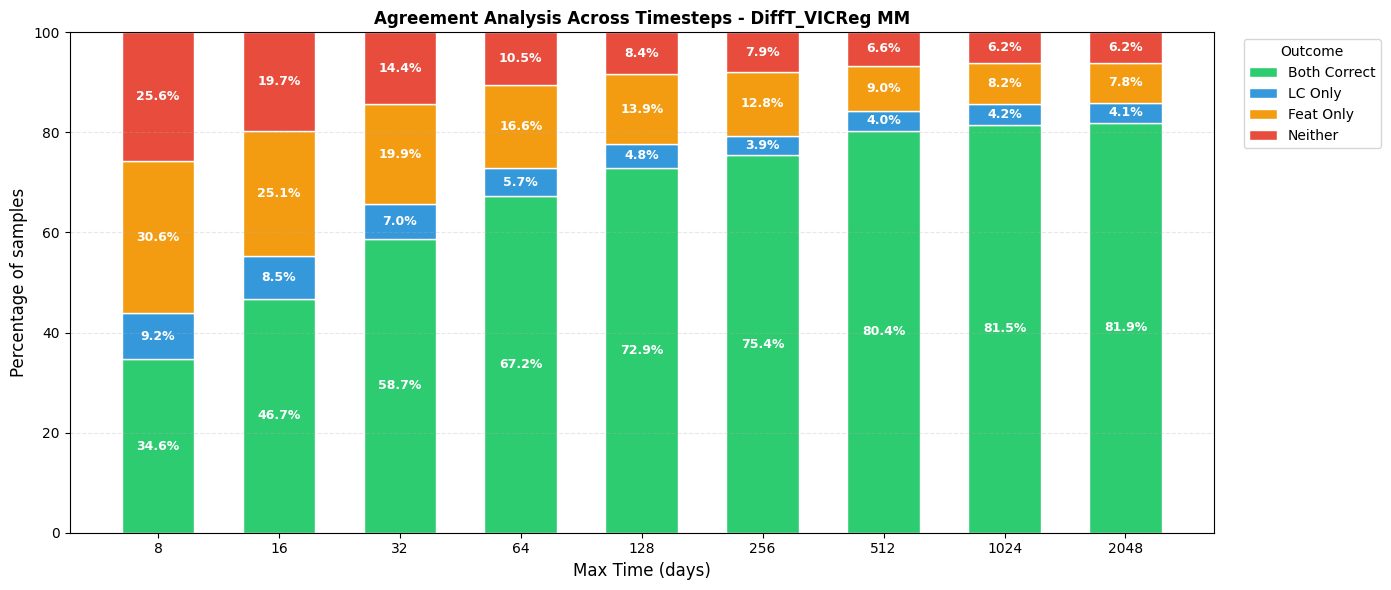

In [ ]:
# Example usage: Load and analyze an experiment at multiple timesteps
exp_dict = experiments_mm[2]  # Select an experiment
split_idx = 0  # Select a split
max_time_values = exp_dict['max_time_to_eval']  # All timesteps to evaluate

print(f"Loading experiment: {exp_dict['experiment_name']}")
print(f"Evaluating at timesteps: {max_time_values}\n")

# Store all analyses for comparison
all_analyses = []

for max_time in max_time_values:
    predictions = load_multimodal_predictions_timestep(exp_dict, split_idx=split_idx, max_time=max_time)
    
    if predictions and predictions['targets'] is not None:
        analysis = analyze_multimodal_predictions_timestep(
            targets=predictions['targets'],
            logits_lcs=predictions['logits_lcs'],
            logits_feat=predictions['logits_feat'],
            logits_mean=predictions['logits_mean'],
            max_time=max_time
        )
        all_analyses.append(analysis)
        print_multimodal_analysis_timestep(analysis, title=f"{exp_dict['experiment_name']}", show_plot=False)

# Plot stacked bar chart across all timesteps
if all_analyses:
    plot_agreement_stacked_bars_timesteps(all_analyses, exp_dict['experiment_name'])
else:
    print("No analyses to plot.")


In [11]:
# Define your experiments with the structure: type, name, experiment_name, max_time_to_eval
experiments_mm = [
    {   'type': 'multimodal',
        'name': 'ATAT_Periodic_MM_2025-10-09_14-01-07',
        'experiment_name': 'ATAT MM',
        'max_time_to_eval': [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
    },
    {   'type': 'multimodal',
        'name': 'DiT_Periodic_MM_2025-10-09_18-22-05',
        'experiment_name': 'DiffT MM',
        'max_time_to_eval': [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
    },
    {   'type': 'multimodal',
        'name': 'DiT_Periodic_VICReg_MM_2025-10-13_07-41-01',
        'experiment_name': 'DiffT_VICReg MM',
        'max_time_to_eval': [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
    }
]

Loading experiment: DiffT_VICReg MM
Evaluating at timesteps: [8, 16, 32, 64, 128, 256, 512, 1024, 2048]



Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


  Loading split 0 (data split: 0) (max_time=8)...
Loading pre-trained weights from /home/fsoto/Documents/LCsSSL/logs/pre_trained_models/VICReg_dit/1/checkpoints/epoch_0279.ckpt


You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


Checkpoint keys: ['network.transformer_lc.stacked_encoders.0.norm1.weight', 'network.transformer_lc.stacked_encoders.0.norm1.bias', 'network.transformer_lc.stacked_encoders.0.norm2.weight', 'network.transformer_lc.stacked_encoders.0.norm2.bias', 'network.transformer_lc.stacked_encoders.0.attn.qkv_proj.weight']
Model has 55 parameters
Checkpoint has 55 parameters for network
Sample model keys: ['transformer_lc.stacked_encoders.2.attn.qkv_proj.weight', 'transformer_lc.stacked_encoders.2.attn.out_proj.weight', 'time_encoder.time_encoders.1.rate_emb.0.weight', 'transformer_lc.stacked_encoders.1.attn.out_proj.weight', 'transformer_lc.stacked_encoders.2.ff.net.0.weight']
Sample checkpoint keys: ['transformer_lc.stacked_encoders.2.attn.qkv_proj.weight', 'transformer_lc.stacked_encoders.2.attn.out_proj.weight', 'time_encoder.time_encoders.1.rate_emb.0.weight', 'transformer_lc.stacked_encoders.1.attn.out_proj.weight', 'transformer_lc.stacked_encoders.2.ff.net.0.weight']
✓ Successfully loaded li

...

✓ Loaded DiT_Periodic_VICReg_MM_2025-10-13_07-41-01 (split 0) (max_time=1024)

DiffT_VICReg MM (max_time=1024)
Total Samples: 4569

------------------------------------------------------------
OVERALL ACCURACY
------------------------------------------------------------
LC Modality Accuracy:       85.66%
Feature Modality Accuracy:  89.63%
Mean Logits Accuracy:       90.90%

------------------------------------------------------------
F1 SCORES (Weighted)
------------------------------------------------------------
LC Modality F1:       0.8591
Feature Modality F1:  0.8962
Mean Logits F1:       0.9092

------------------------------------------------------------
AGREEMENT ANALYSIS
------------------------------------------------------------
Both Correct:       3722 ( 81.46%)
LC Only Correct:     192 (  4.20%)
Feat Only Correct:   373 (  8.16%)
Neither Correct:     282 (  6.17%)



Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


  Loading split 0 (data split: 0) (max_time=2048)...
Loading pre-trained weights from /home/fsoto/Documents/LCsSSL/logs/pre_trained_models/VICReg_dit/1/checkpoints/epoch_0279.ckpt
Checkpoint keys: ['network.transformer_lc.stacked_encoders.0.norm1.weight', 'network.transformer_lc.stacked_encoders.0.norm1.bias', 'network.transformer_lc.stacked_encoders.0.norm2.weight', 'network.transformer_lc.stacked_encoders.0.norm2.bias', 'network.transformer_lc.stacked_encoders.0.attn.qkv_proj.weight']
Model has 55 parameters
Checkpoint has 55 parameters for network
Sample model keys: ['transformer_lc.stacked_encoders.2.attn.qkv_proj.weight', 'transformer_lc.stacked_encoders.2.attn.out_proj.weight', 'time_encoder.time_encoders.1.rate_emb.0.weight', 'transformer_lc.stacked_encoders.1.attn.out_proj.weight', 'transformer_lc.stacked_encoders.2.ff.net.0.weight']
Sample checkpoint keys: ['transformer_lc.stacked_encoders.2.attn.qkv_proj.weight', 'transformer_lc.stacked_encoders.2.attn.out_proj.weight', 'time

Restoring states from the checkpoint path at ../logs/multimodal/DiT_Periodic_VICReg_MM_2025-10-13_07-41-01/0/checkpoints/epoch_0091.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at ../logs/multimodal/DiT_Periodic_VICReg_MM_2025-10-13_07-41-01/0/checkpoints/epoch_0091.ckpt


✓ Loaded DiT_Periodic_VICReg_MM_2025-10-13_07-41-01 (split 0) (max_time=2048)

DiffT_VICReg MM (max_time=2048)
Total Samples: 4569

------------------------------------------------------------
OVERALL ACCURACY
------------------------------------------------------------
LC Modality Accuracy:       85.97%
Feature Modality Accuracy:  89.67%
Mean Logits Accuracy:       91.00%

------------------------------------------------------------
F1 SCORES (Weighted)
------------------------------------------------------------
LC Modality F1:       0.8623
Feature Modality F1:  0.8967
Mean Logits F1:       0.9105

------------------------------------------------------------
AGREEMENT ANALYSIS
------------------------------------------------------------
Both Correct:       3740 ( 81.86%)
LC Only Correct:     188 (  4.11%)
Feat Only Correct:   357 (  7.81%)
Neither Correct:     284 (  6.22%)



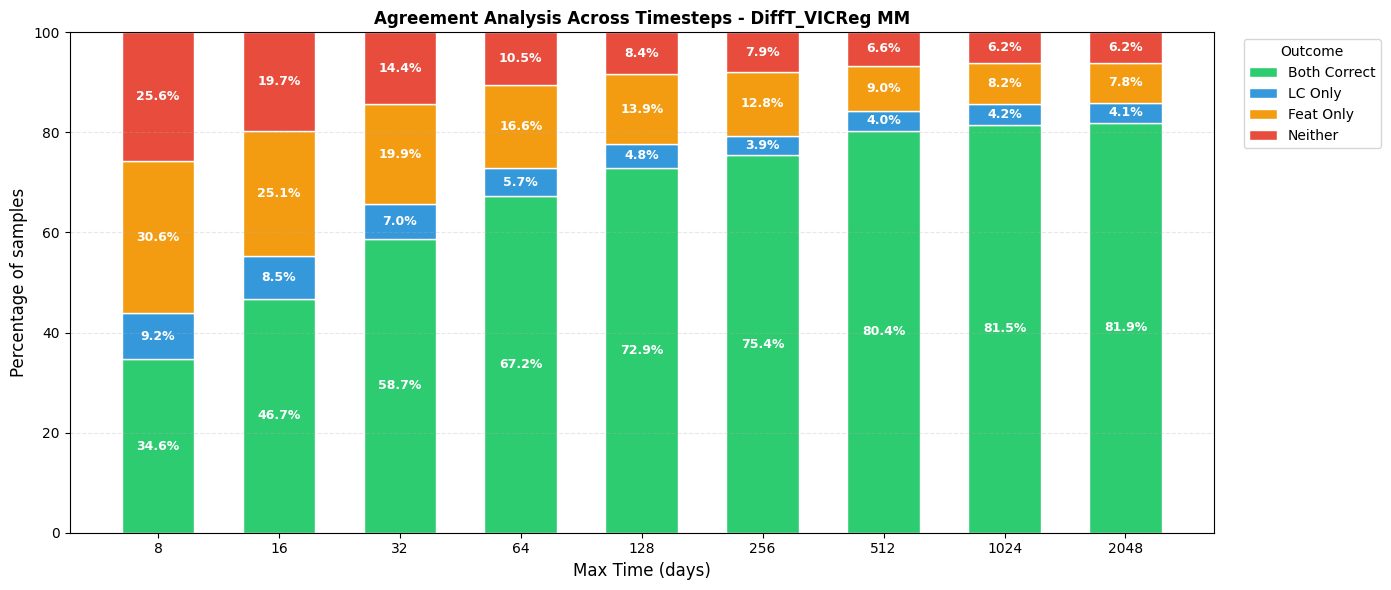

In [12]:
# Example usage: Load and analyze an experiment at multiple timesteps
exp_dict = experiments_mm[2]  # Select an experiment
split_idx = 0  # Select a split
max_time_values = exp_dict['max_time_to_eval']  # All timesteps to evaluate

print(f"Loading experiment: {exp_dict['experiment_name']}")
print(f"Evaluating at timesteps: {max_time_values}\n")

# Store all analyses for comparison
all_analyses = []

for max_time in max_time_values:
    predictions = load_multimodal_predictions_timestep(exp_dict, split_idx=split_idx, max_time=max_time)
    
    if predictions and predictions['targets'] is not None:
        analysis = analyze_multimodal_predictions_timestep(
            targets=predictions['targets'],
            logits_lcs=predictions['logits_lcs'],
            logits_feat=predictions['logits_feat'],
            logits_mean=predictions['logits_mean'],
            max_time=max_time
        )
        all_analyses.append(analysis)
        print_multimodal_analysis_timestep(analysis, title=f"{exp_dict['experiment_name']}", show_plot=False)

# Plot stacked bar chart across all timesteps
if all_analyses:
    plot_agreement_stacked_bars_timesteps(all_analyses, exp_dict['experiment_name'])
else:
    print("No analyses to plot.")


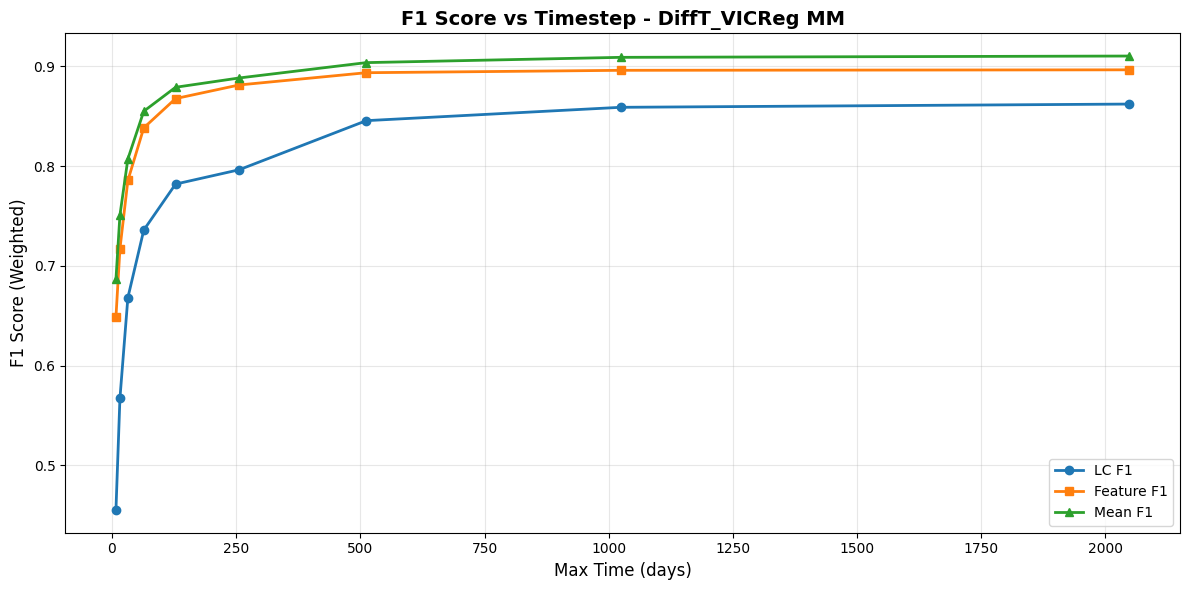

In [13]:
# Plot F1 scores across timesteps
import matplotlib.pyplot as plt

if all_analyses:
    timesteps = [a['metrics']['max_time'] for a in all_analyses]
    lcs_f1_scores = [a['metrics']['lcs_f1'] for a in all_analyses]
    feat_f1_scores = [a['metrics']['feat_f1'] for a in all_analyses]
    mean_f1_scores = [a['metrics'].get('mean_f1', None) for a in all_analyses]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(timesteps, lcs_f1_scores, marker='o', label='LC F1', linewidth=2)
    ax.plot(timesteps, feat_f1_scores, marker='s', label='Feature F1', linewidth=2)
    if any(m is not None for m in mean_f1_scores):
        ax.plot(timesteps, mean_f1_scores, marker='^', label='Mean F1', linewidth=2)
    
    ax.set_xlabel('Max Time (days)', fontsize=12)
    ax.set_ylabel('F1 Score (Weighted)', fontsize=12)
    ax.set_title(f'F1 Score vs Timestep - {exp_dict["experiment_name"]}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()